# Загрузка модели

In [2]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from grokking_carries.config import ModelConfig
from grokking_carries.model.transformer import GrokkingCarriesTransformer
from grokking_carries.data.tokenizer import MathTokenizer

model_cfg = ModelConfig()
model = GrokkingCarriesTransformer(model_cfg)
tokenizer = MathTokenizer()

save_dir = os.path.abspath(os.path.join(project_root, "src", "grokking_carries", "model"))
save_path = os.path.join(save_dir, "grokking_model_5_epochs.pth")

model.load_state_dict(torch.load(save_path, map_location=model_cfg.device, weights_only=True))
model.to(model_cfg.device)
model.eval()

print("Модель загружена.")

# Примеры для анализа

# Корректный пример
clean_prompt = "0 0 5 0 2 - 0 0 0 1 9 ="
clean_target = "<b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0"

# Пример, на котором модель ошибается
corrupted_prompt = "6 9 0 1 2 - 3 4 6 8 0 ="
corrupted_target = "<b0> 2 <b1> 3 <b1> 3 <b0> 4 <b0> 3"

def prepare_tensor(prompt: str, target: str, tokenizer, device):
    full_text = f"{prompt} {target}"
    tokens = tokenizer.encode(full_text, from_split=True)
    return torch.tensor([tokens], dtype=torch.long).to(device), tokens

clean_tensor, clean_tokens = prepare_tensor(clean_prompt, clean_target, tokenizer, model_cfg.device)
str_tokens = [tokenizer.i2v[t] for t in clean_tokens] # Строковые токены для осей графиков

print(f"Исследуем последовательность из {len(str_tokens)} токенов.")

Модель загружена.
Исследуем последовательность из 22 токенов.


**Поработаем с вычитанием**

# Извлечение матриц внимания 

Матрицы внимания извлечены. В кэше 4 слоев.


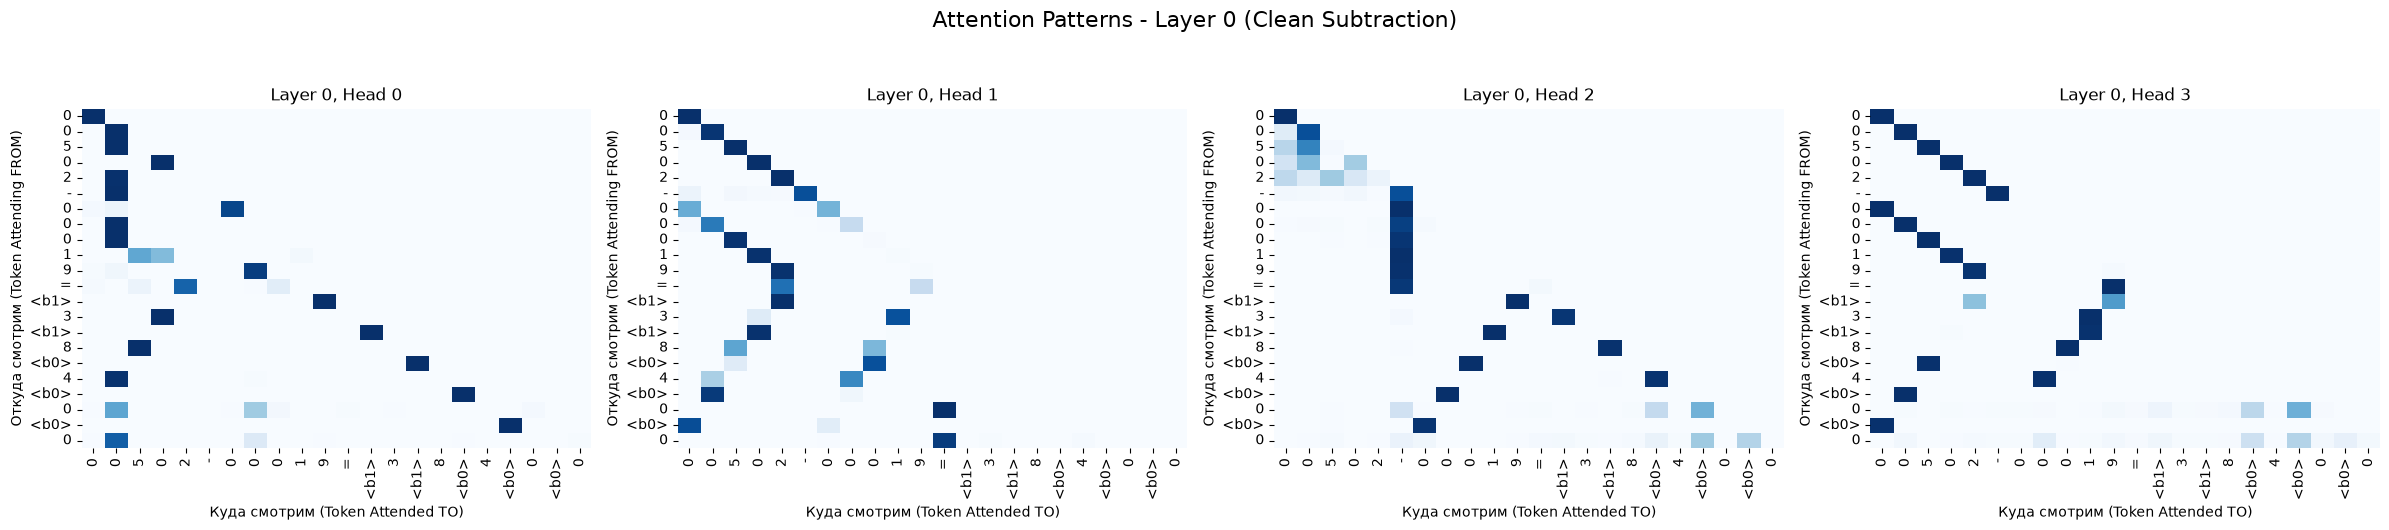

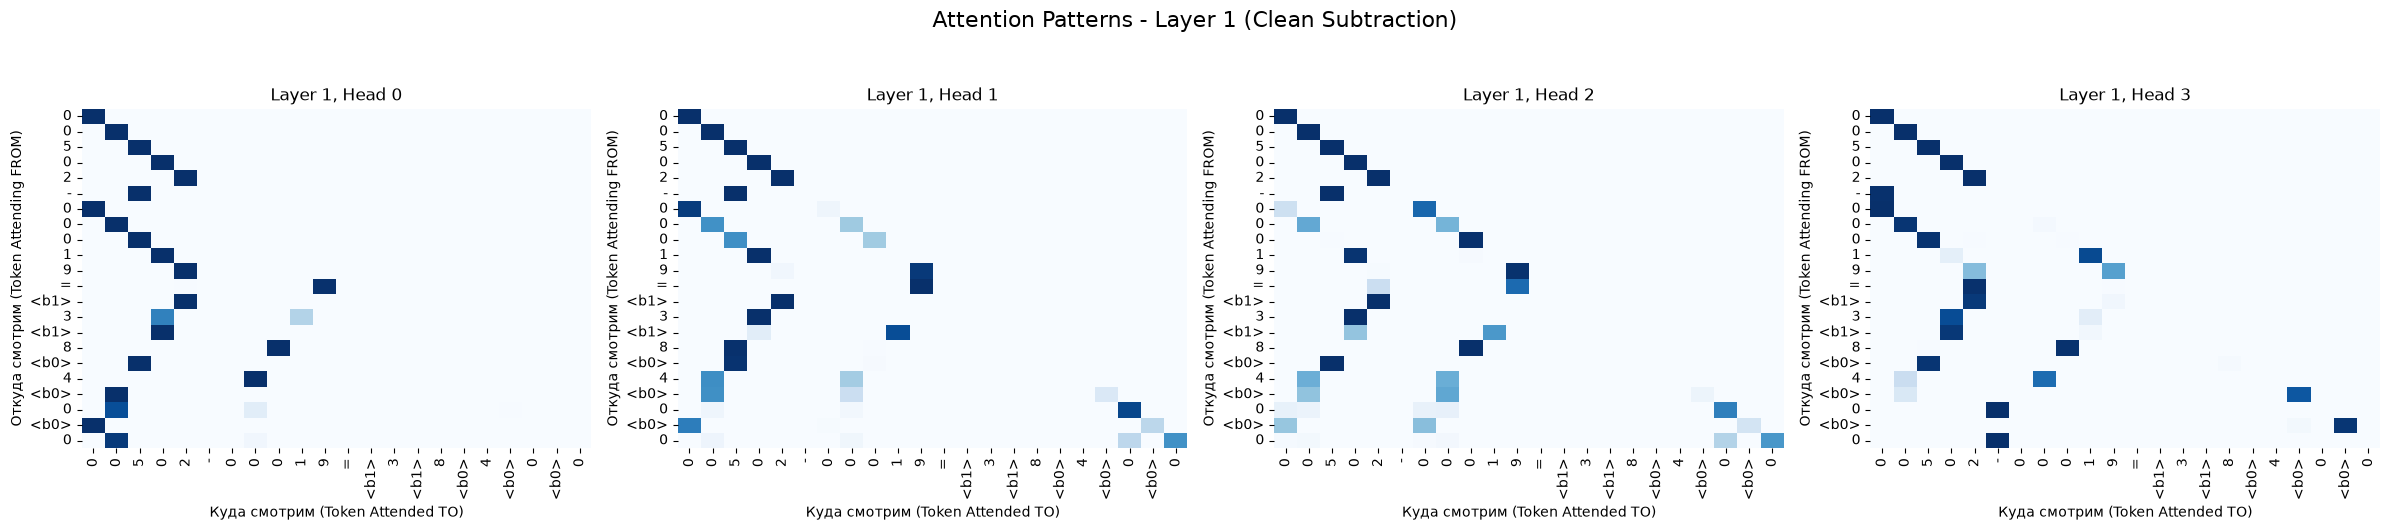

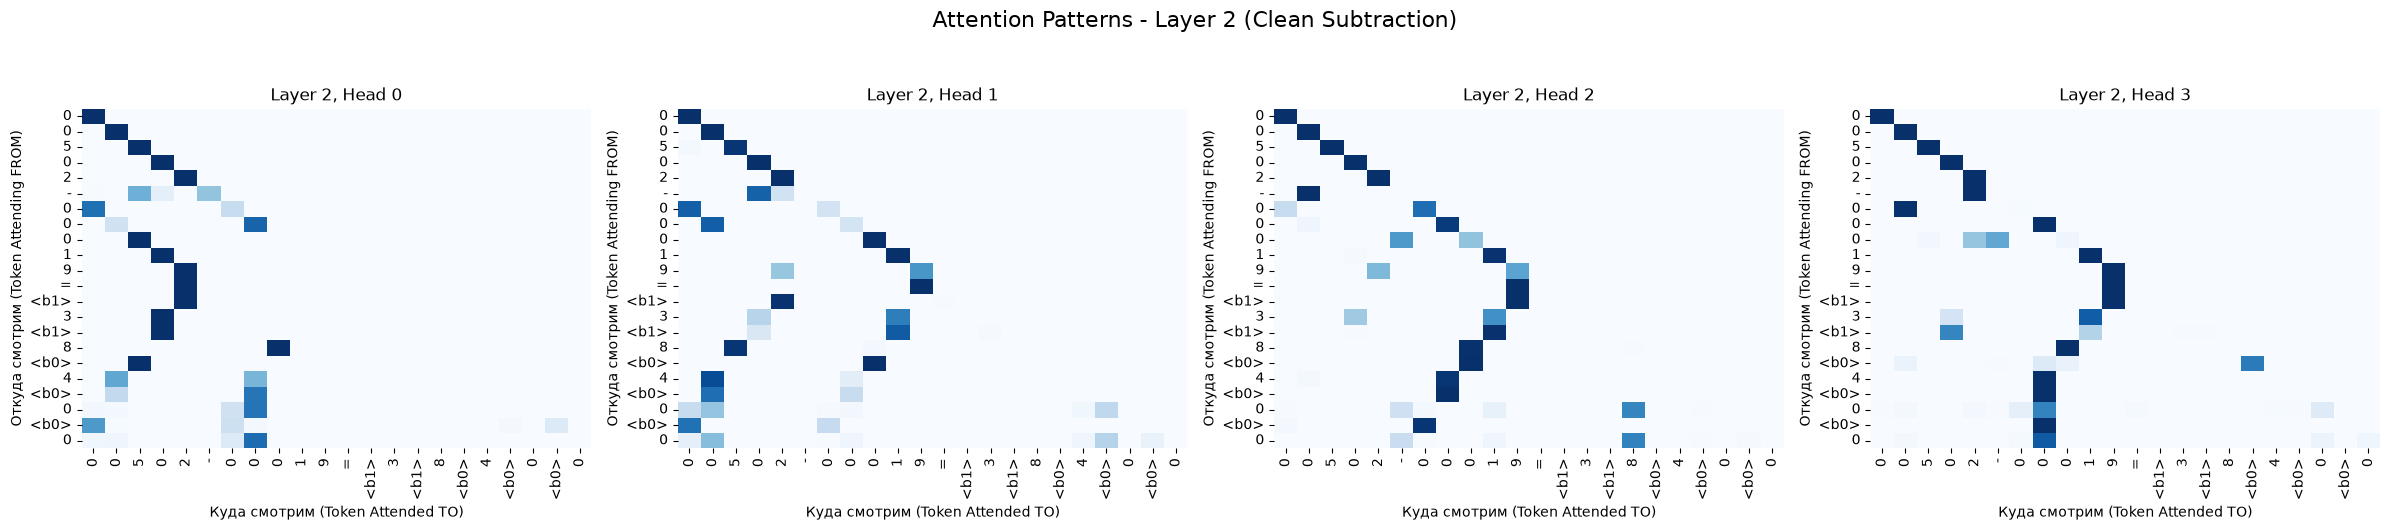

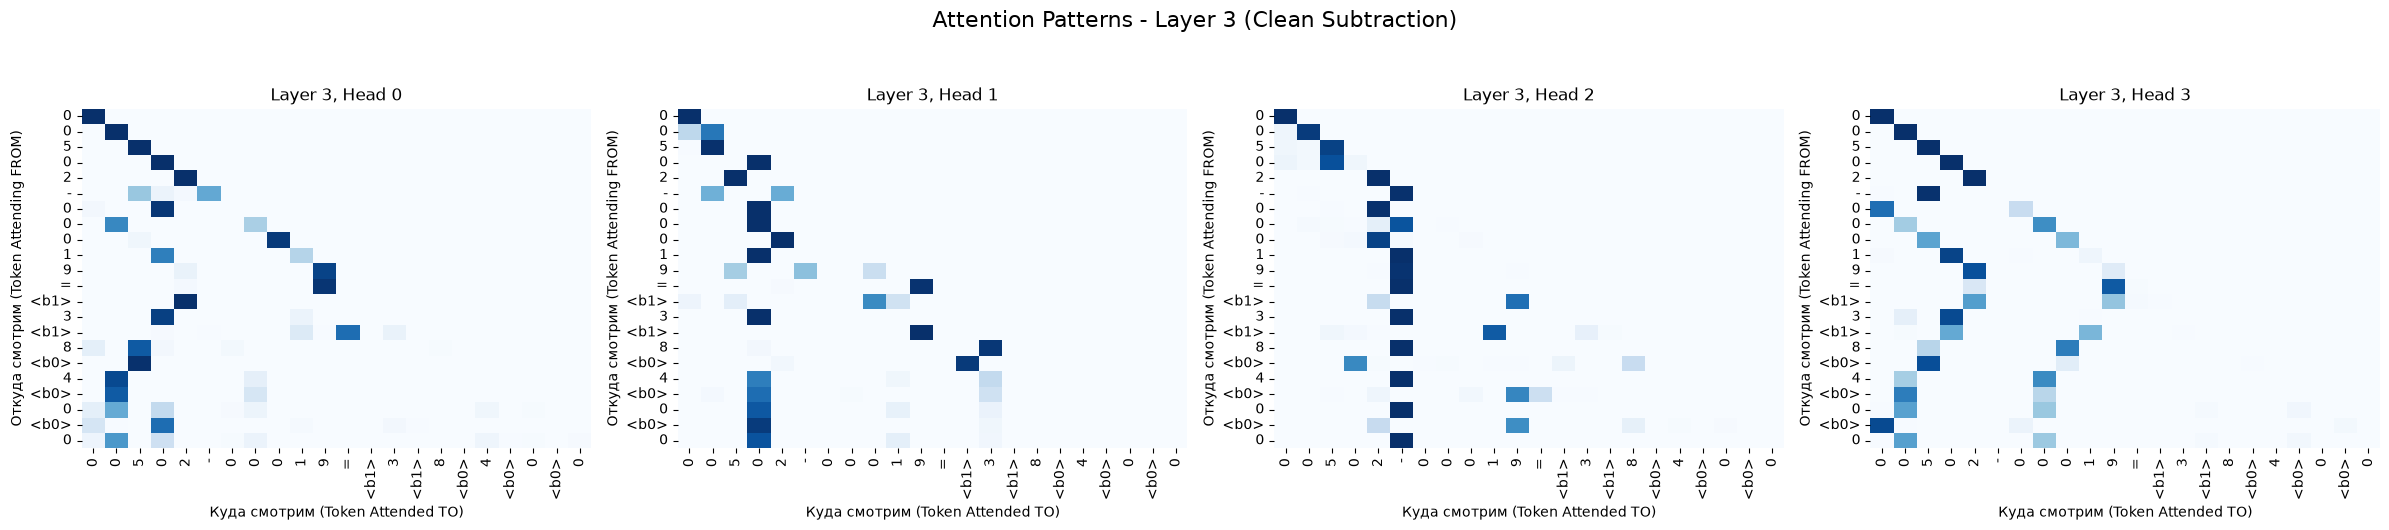

In [6]:
# Словарь для кэширования матриц внимания
cache = {}

# Функция для перехвата тензора
def save_attention_pattern_hook(tensor, hook_name):
    cache[hook_name] = tensor.detach().cpu()
    return tensor

hooks_to_add = []
for layer in range(model_cfg.n_layers):
    hook_name = f"blocks.{layer}.attn.hook_pattern"
    hooks_to_add.append((hook_name, save_attention_pattern_hook))

with model.hooks(fwd_hooks=hooks_to_add):
    _ = model(clean_tensor)

print(f"Матрицы внимания извлечены. В кэше {len(cache)} слоев.")

# Отрисовка визуализации
def plot_attention_layer(cache_dict, layer_idx: int, str_tokens: list, title_suffix=""):
    hook_name = f"blocks.{layer_idx}.attn.hook_pattern"
    pattern = cache_dict[hook_name][0] 
    n_heads = pattern.shape[0]
    
    fig, axes = plt.subplots(1, n_heads, figsize=(6 * n_heads, 5))
    if n_heads == 1:
        axes = [axes]
        
    for head_idx in range(n_heads):
        ax = axes[head_idx]
        head_pattern = pattern[head_idx].numpy()
        
        sns.heatmap(
            head_pattern, 
            cmap="Blues", 
            cbar=False, 
            xticklabels=str_tokens, 
            yticklabels=str_tokens,
            ax=ax
        )
        ax.set_title(f"Layer {layer_idx}, Head {head_idx}")
        ax.tick_params(axis='x', rotation=90)
        ax.tick_params(axis='y', rotation=0)
        ax.set_xlabel("Куда смотрим (Token Attended TO)")
        ax.set_ylabel("Откуда смотрим (Token Attending FROM)")
        
    plt.suptitle(f"Attention Patterns - Layer {layer_idx} {title_suffix}", y=1.05, fontsize=16)
    plt.tight_layout()
    plt.show()

for layer in range(model_cfg.n_layers):
    plot_attention_layer(cache, layer, str_tokens, title_suffix="(Clean Subtraction)")

# Проанализируем что будет происходить при поочерёдном отключении голов

In [8]:
prompt_len = len(tokenizer.encode(clean_prompt, from_split=True))
start_idx = prompt_len - 1 

def get_ablation_hook(head_idx_to_ablate):
    def custom_zero_ablation_hook(z_tensor, hook):
        ablated_z = z_tensor.clone()
        # Выключаем строго заданную голову
        ablated_z[:, :, head_idx_to_ablate, :] = 0.0
        return ablated_z
    return custom_zero_ablation_hook

print("Отключаем головы по очереди")
print(f"Промпт:   {clean_prompt}")
print(f"Ожидали:  {clean_target}\n")
print("-" * 50)

broken_count = 0

# Проходимся по всем слоям и всем головам
for layer in range(model_cfg.n_layers):
    for head in range(model_cfg.n_heads):
        hook_name = f"blocks.{layer}.attn.hook_z"
        
        with torch.no_grad():
            with model.hooks(fwd_hooks=[(hook_name, get_ablation_hook(head))]):
                logits = model(clean_tensor)
                preds = torch.argmax(logits[0, start_idx:-1, :], dim=-1).tolist()
                got = tokenizer.decode(preds).strip()
                
                # Проверяем, сломался ли ответ
                if got == clean_target.strip():
                    status = "Ответ корректен"
                else:
                    status = "Ответ сломался"
                    broken_count += 1
                
                print(f"Без Layer {layer}, Head {head} | {status} | Вывод: {got}")

print("-" * 50)
print(f"Из {model_cfg.n_layers * model_cfg.n_heads} голов отключение одной сломало ответ в {broken_count} случаях.")

Отключаем головы по очереди
Промпт:   0 0 5 0 2 - 0 0 0 1 9 =
Ожидали:  <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0

--------------------------------------------------
Без Layer 0, Head 0 | Ответ сломался | Вывод: <b1> 3 <b1> 8 <b0> 5 <b0> 0 <b0> 0
Без Layer 0, Head 1 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 0, Head 2 | Ответ сломался | Вывод: <b1> 3 <b1> 1 <b0> 4 <b0> 0 <b0> 0
Без Layer 0, Head 3 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 1, Head 0 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 1, Head 1 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 1, Head 2 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 1, Head 3 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 2, Head 0 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 2, Head 1 | Ответ корректен | Вывод: <b1> 3 <b1> 8 <b0> 4 <b0> 0 <b0> 0
Без Layer 2, Head 2 | О

**По результатам имеем гиппотезы:**
* Layer 0, Head 0 отвечала за исполнение операции заёма
* Layer 0, Head 2 отвечала за арифметику вычисления разряда
* Layer 3, Head 2 отвечала за генерацию токена исполняемой операции

# Изучим глобальную точность при поочерёдном отключении голов

Собрано примеров на вычитание: 1000
Размерность тензора: torch.Size([1000, 24])

Базовая точность здоровой модели на этом батче: 99.70%
Запуск поочередного отключения голов


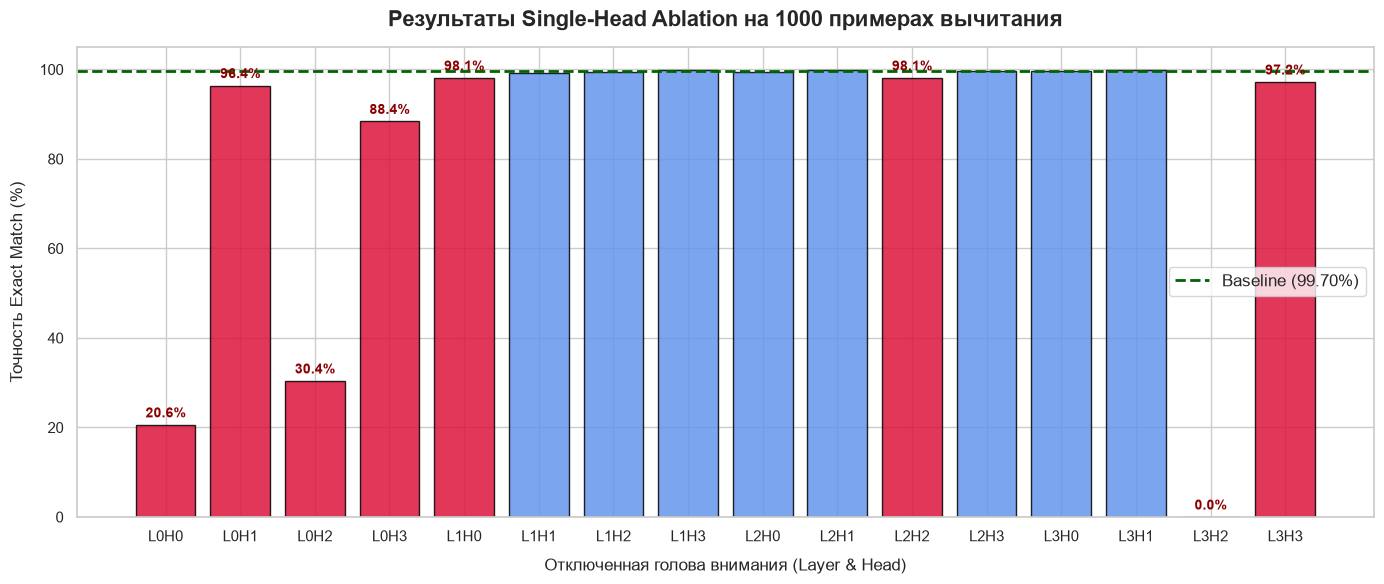

In [11]:
import json
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# 1000 примеров на вычитание
sub_examples = []
test_file_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "test.jsonl"))

with open(test_file_path, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        
        # Только вычитание
        if '-' in record['prompt']:
            tokens = tokenizer.encode(record['text'], from_split=True)
            sub_examples.append(torch.tensor(tokens, dtype=torch.long))
            
        if len(sub_examples) >= 1000:
            break

# Собираем в один большой тензор [1000, seq_len]
sub_eval_tokens = torch.stack(sub_examples).to(model_cfg.device)
print(f"Собрано примеров на вычитание: {sub_eval_tokens.size(0)}")
print(f"Размерность тензора: {sub_eval_tokens.shape}")

def evaluate_exact_match(model, eval_tokens, model_cfg, eq_token_id=12):
    correct_count = 0
    total_count = eval_tokens.size(0)
    batch_size = 128
    
    for start_idx_b in range(0, total_count, batch_size):
        batch = eval_tokens[start_idx_b : start_idx_b + batch_size]
        
        logits = model(batch)
        preds = torch.argmax(logits[:, :-1, :], dim=-1)
        targets = batch[:, 1:]
        
        for i in range(batch.size(0)):
            eq_pos = (batch[i] == eq_token_id).nonzero(as_tuple=True)[0]
            
            if len(eq_pos) > 0:
                start_idx = eq_pos[0]
                pad_pos = (targets[i] == model_cfg.pad_token_id).nonzero(as_tuple=True)[0]
                end_idx = pad_pos[0] if len(pad_pos) > 0 else targets.size(1)
                
                if torch.equal(preds[i, start_idx:end_idx], targets[i, start_idx:end_idx]):
                    correct_count += 1
                    
    return correct_count / total_count

# Замеряем базовую точность здоровой модели
baseline_acc = evaluate_exact_match(model, sub_eval_tokens, model_cfg)
print(f"\nБазовая точность здоровой модели на этом батче: {baseline_acc * 100:.2f}%")

head_labels = []
accuracies = []

def get_ablation_hook(head_to_null):
    def hook(z_tensor, hook):
        ablated_z = z_tensor.clone()
        ablated_z[:, :, head_to_null, :] = 0.0
        return ablated_z
    return hook

print("Запуск поочередного отключения голов")
for layer in range(model_cfg.n_layers):
    for head in range(model_cfg.n_heads):
        hook_name = f"blocks.{layer}.attn.hook_z"
        label = f"L{layer}H{head}"
        head_labels.append(label)
        
        with model.hooks(fwd_hooks=[(hook_name, get_ablation_hook(head))]):
            acc = evaluate_exact_match(model, sub_eval_tokens, model_cfg)
            accuracies.append(acc * 100)

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Подсвечиваем красным те головы, которые роняют точность ниже базовой
colors = ['crimson' if acc < (baseline_acc*100 - 1) else 'cornflowerblue' for acc in accuracies]
bars = plt.bar(head_labels, accuracies, color=colors, edgecolor='black', alpha=0.85)

plt.axhline(y=baseline_acc * 100, color='darkgreen', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc*100:.2f}%)')

for bar, acc in zip(bars, accuracies):
    if acc < (baseline_acc*100 - 0.5):
        plt.text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + 1, f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred')

plt.title("Результаты Single-Head Ablation на 1000 примерах вычитания", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Отключенная голова внимания (Layer & Head)", fontsize=12, labelpad=10)
plt.ylabel("Точность Exact Match (%)", fontsize=12, labelpad=10)
plt.ylim(0, 105)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

**Подтвердили гиппотезы касательно L0H0, L0H2, L3H2**

# Проделаем аналогичные процедуры со сложением

Исследуем последовательность из 22 токенов.
Матрицы внимания извлечены. В кэше 4 слоев.


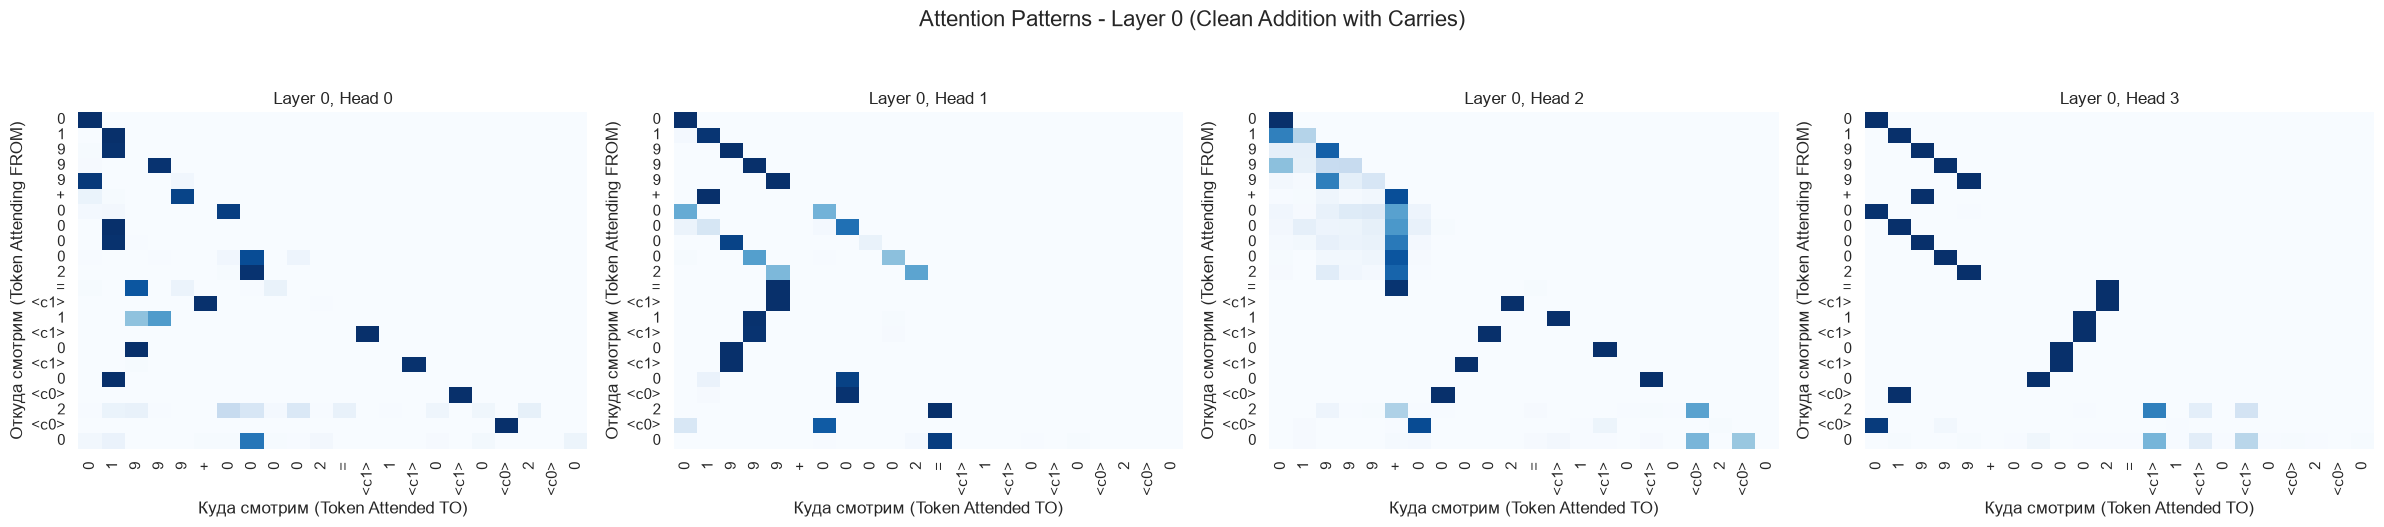

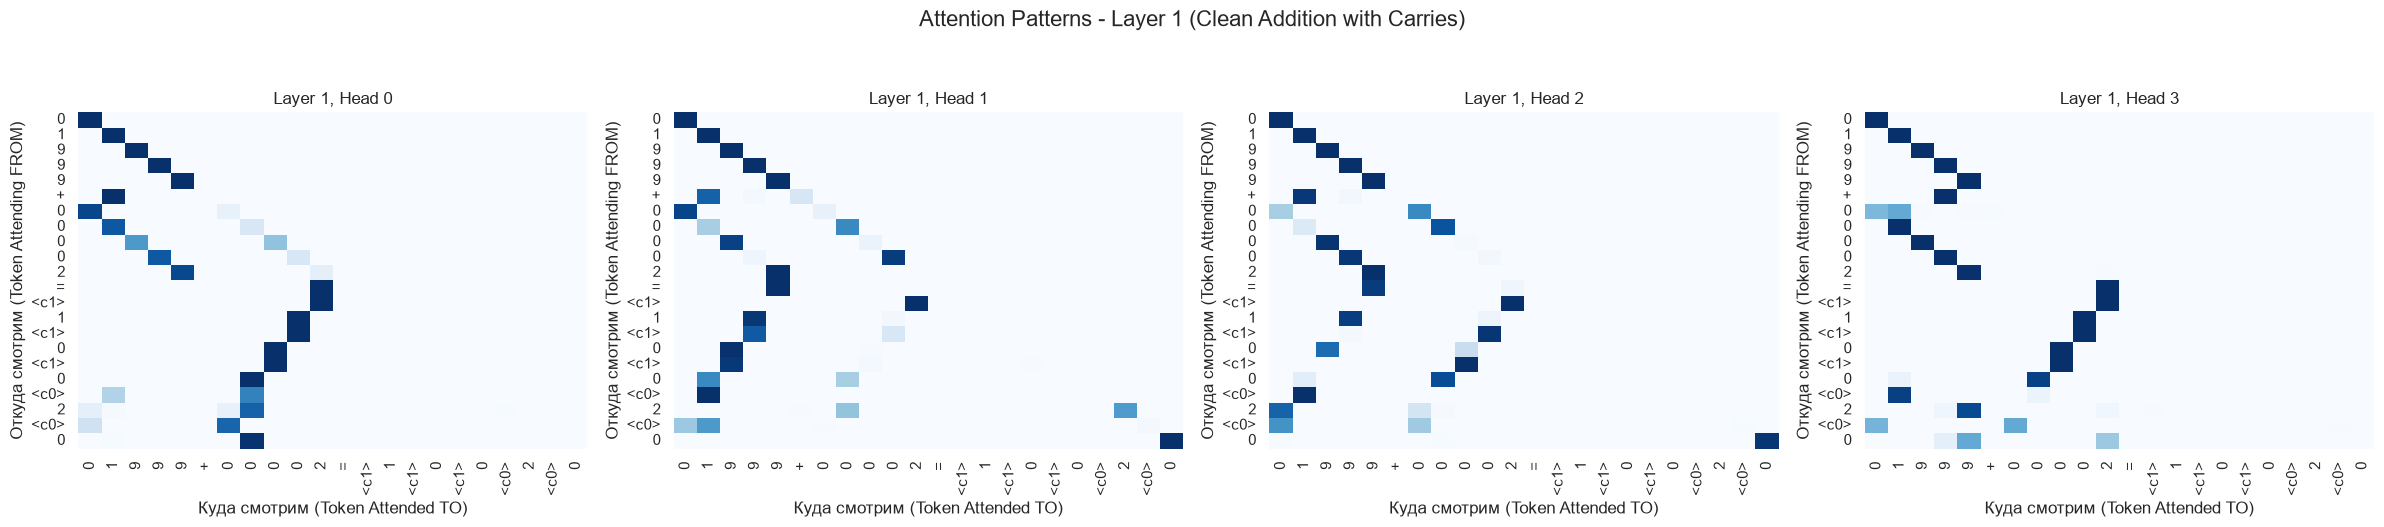

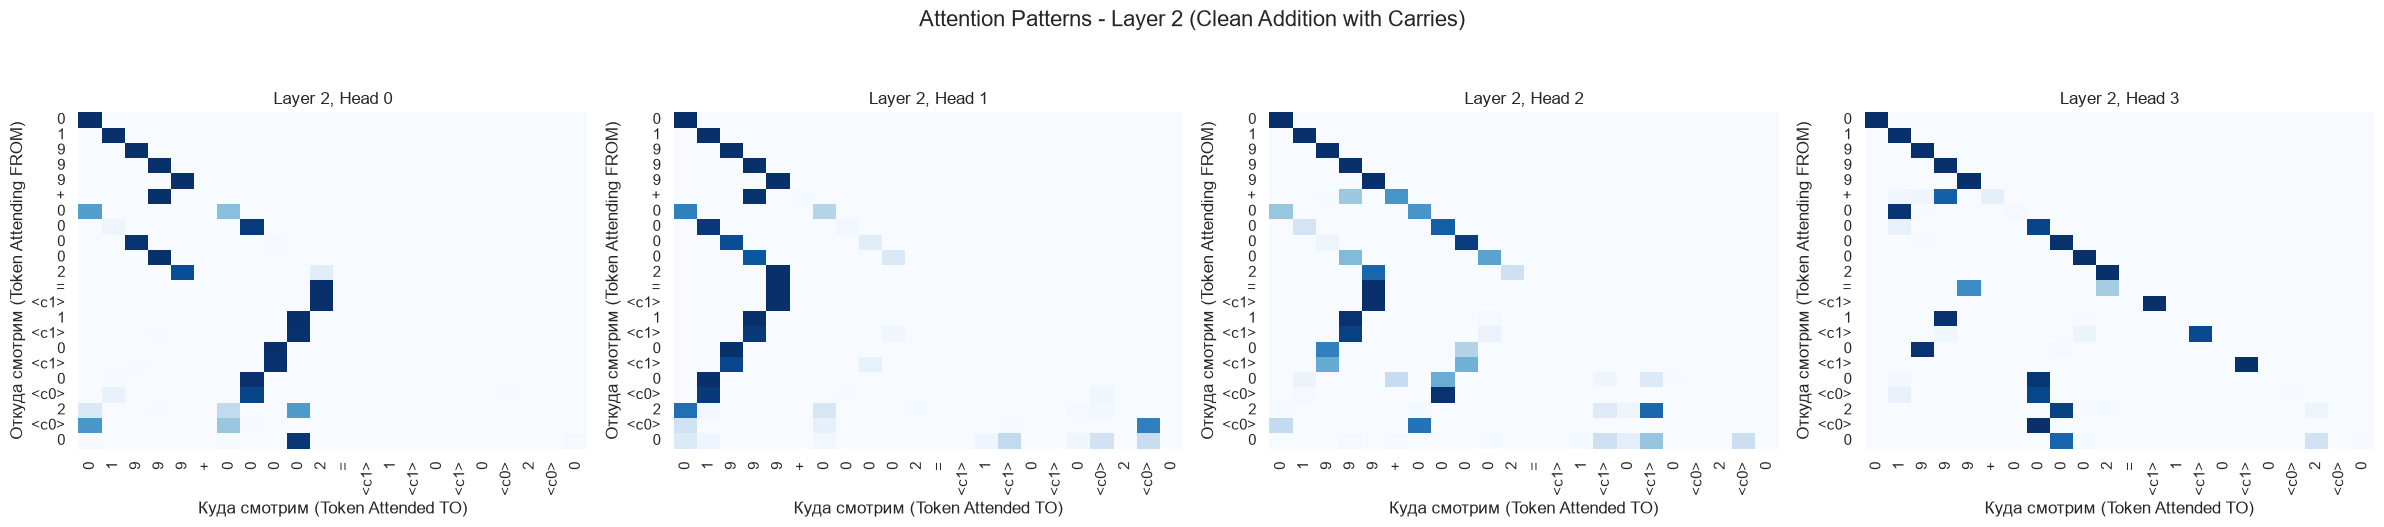

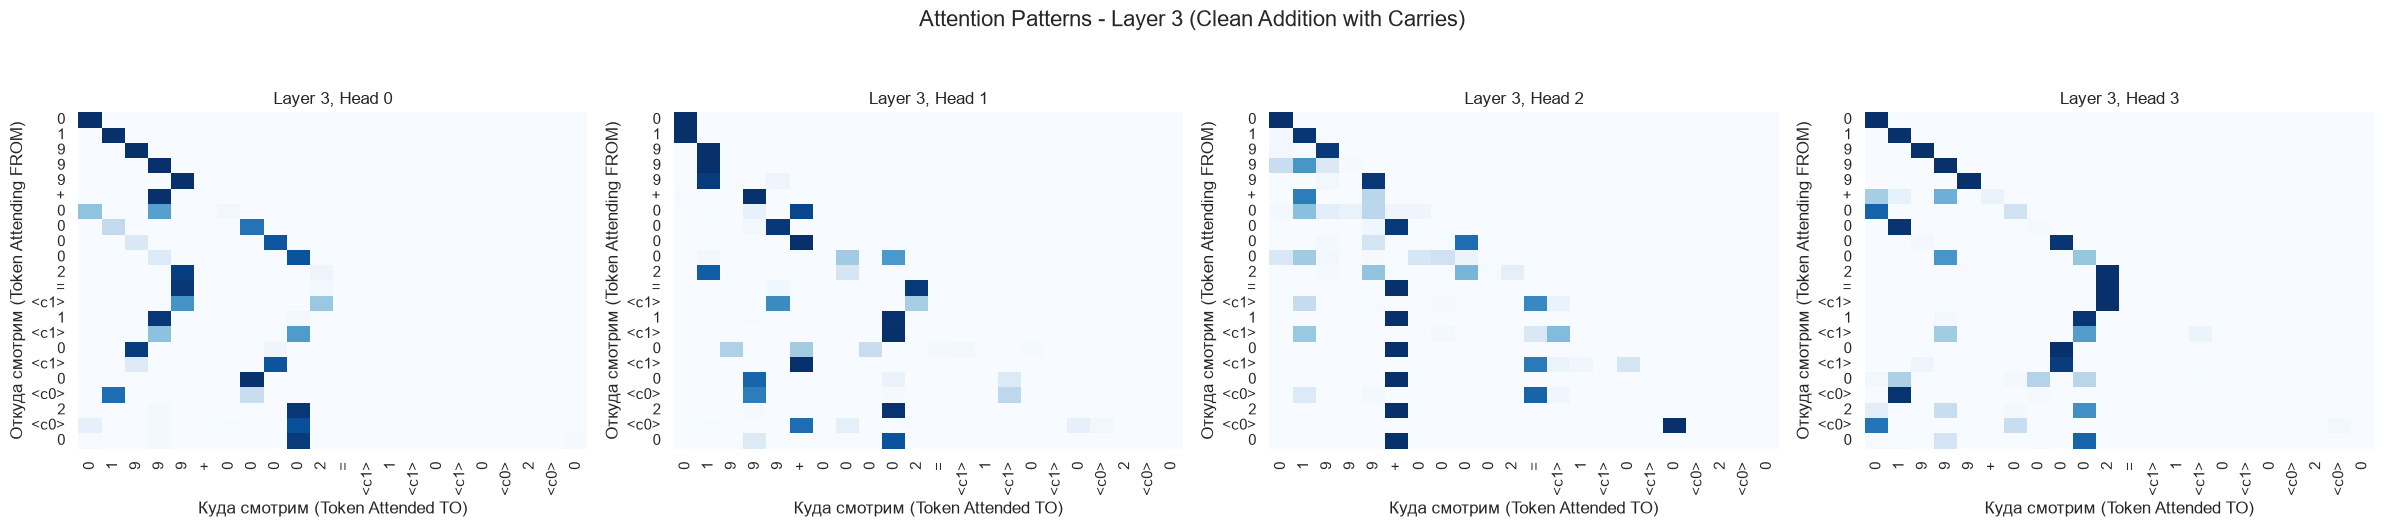

In [13]:
add_prompt = "0 1 9 9 9 + 0 0 0 0 2 ="
add_target = "<c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0"

add_tensor, add_tokens = prepare_tensor(add_prompt, add_target, tokenizer, model_cfg.device)
str_tokens_add = [tokenizer.i2v[t] for t in add_tokens]

print(f"Исследуем последовательность из {len(str_tokens_add)} токенов.")

cache = {}  

def save_attention_pattern_hook(tensor, hook_name):
    cache[hook_name] = tensor.detach().cpu()
    return tensor

hooks_to_add = []
for layer in range(model_cfg.n_layers):
    hook_name = f"blocks.{layer}.attn.hook_pattern"
    hooks_to_add.append((hook_name, save_attention_pattern_hook))

with model.hooks(fwd_hooks=hooks_to_add):
    _ = model(add_tensor)

print(f"Матрицы внимания извлечены. В кэше {len(cache)} слоев.")

for layer in range(model_cfg.n_layers):
    plot_attention_layer(cache, layer, str_tokens_add, title_suffix="(Clean Addition with Carries)")

# Проанализируем что будет происходить при поочерёдном отключении голов

In [15]:
prompt_len = len(tokenizer.encode(add_prompt, from_split=True))
start_idx = prompt_len - 1 

def get_ablation_hook(head_idx_to_ablate):
    def custom_zero_ablation_hook(z_tensor, hook):
        ablated_z = z_tensor.clone()
        # Выключаем строго заданную голову
        ablated_z[:, :, head_idx_to_ablate, :] = 0.0
        return ablated_z
    return custom_zero_ablation_hook

print("Отключаем головы по очереди")
print(f"Промпт:   {add_prompt}")
print(f"Ожидали:  {add_target}\n")
print("-" * 50)

broken_count = 0

# Проходимся по всем слоям и всем головам
for layer in range(model_cfg.n_layers):
    for head in range(model_cfg.n_heads):
        hook_name = f"blocks.{layer}.attn.hook_z"
        
        with torch.no_grad():
            with model.hooks(fwd_hooks=[(hook_name, get_ablation_hook(head))]):
                logits = model(add_tensor)
                preds = torch.argmax(logits[0, start_idx:-1, :], dim=-1).tolist()
                got = tokenizer.decode(preds).strip()
                
                # Проверяем, сломался ли ответ для сложения
                if got == add_target.strip():
                    status = "Ответ корректен"
                else:
                    status = "Ответ сломался"
                    broken_count += 1
                
                print(f"Без Layer {layer}, Head {head} | {status} | Вывод: {got}")

print("-" * 50)
print(f"Из {model_cfg.n_layers * model_cfg.n_heads} голов отключение одной сломало ответ в {broken_count} случаях.")

Отключаем головы по очереди
Промпт:   0 1 9 9 9 + 0 0 0 0 2 =
Ожидали:  <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0

--------------------------------------------------
Без Layer 0, Head 0 | Ответ сломался | Вывод: <c1> 2 <c1> 0 <c1> 0 <c0> 1 <c0> 0
Без Layer 0, Head 1 | Ответ корректен | Вывод: <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 0, Head 2 | Ответ сломался | Вывод: <c1> 1 0 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 0, Head 3 | Ответ корректен | Вывод: <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 1, Head 0 | Ответ корректен | Вывод: <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 1, Head 1 | Ответ корректен | Вывод: <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 1, Head 2 | Ответ корректен | Вывод: <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 1, Head 3 | Ответ корректен | Вывод: <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 2, Head 0 | Ответ корректен | Вывод: <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 2, Head 1 | Ответ корректен | Вывод: <c1> 1 <c1> 0 <c1> 0 <c0> 2 <c0> 0
Без Layer 2, Head 2 | Отве

# Изучим глобальную точность при поочерёдном отключении голов

Успешно собрано примеров на сложение: 1000
Размерность тензора: torch.Size([1000, 24])

Базовая точность здоровой модели на сложении: 100.00%
Запуск поочередного отключения голов на примерах сложения...


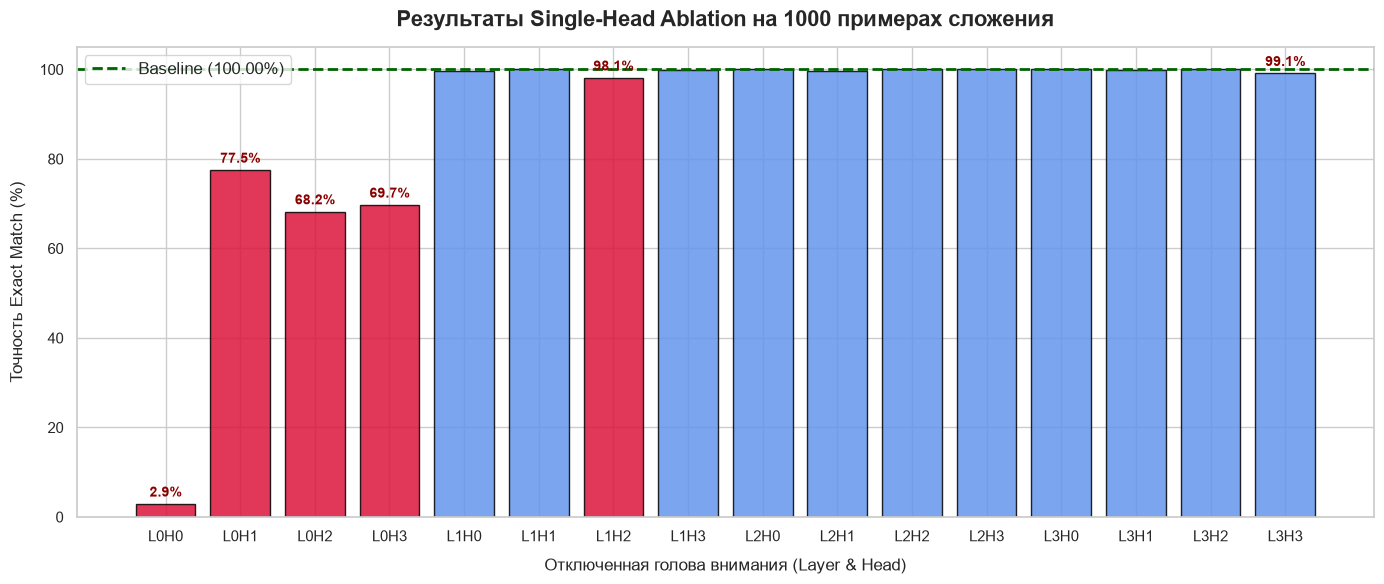

In [17]:
import json
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

add_examples = []
test_file_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "test.jsonl"))

with open(test_file_path, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        
        if '+' in record['prompt']:
            tokens = tokenizer.encode(record['text'], from_split=True)
            add_examples.append(torch.tensor(tokens, dtype=torch.long))
            
        if len(add_examples) >= 1000:
            break

# Собираем в один большой тензор [1000, seq_len]
add_eval_tokens = torch.stack(add_examples).to(model_cfg.device)
print(f"Успешно собрано примеров на сложение: {add_eval_tokens.size(0)}")
print(f"Размерность тензора: {add_eval_tokens.shape}")

def evaluate_exact_match(model, eval_tokens, model_cfg, eq_token_id=12):
    correct_count = 0
    total_count = eval_tokens.size(0)
    batch_size = 128
    
    for start_idx_b in range(0, total_count, batch_size):
        batch = eval_tokens[start_idx_b : start_idx_b + batch_size]
        
        logits = model(batch)
        preds = torch.argmax(logits[:, :-1, :], dim=-1)
        targets = batch[:, 1:]
        
        for i in range(batch.size(0)):
            eq_pos = (batch[i] == eq_token_id).nonzero(as_tuple=True)[0]
            
            if len(eq_pos) > 0:
                start_idx = eq_pos[0]
                pad_pos = (targets[i] == model_cfg.pad_token_id).nonzero(as_tuple=True)[0]
                end_idx = pad_pos[0] if len(pad_pos) > 0 else targets.size(1)
                
                if torch.equal(preds[i, start_idx:end_idx], targets[i, start_idx:end_idx]):
                    correct_count += 1
                    
    return correct_count / total_count

# Замеряем базовую точность здоровой модели
baseline_acc = evaluate_exact_match(model, add_eval_tokens, model_cfg)
print(f"\nБазовая точность здоровой модели на сложении: {baseline_acc * 100:.2f}%")

head_labels = []
accuracies = []

def get_ablation_hook(head_to_null):
    def hook(z_tensor, hook):
        ablated_z = z_tensor.clone()
        ablated_z[:, :, head_to_null, :] = 0.0
        return ablated_z
    return hook

print("Запуск поочередного отключения голов на примерах сложения...")
for layer in range(model_cfg.n_layers):
    for head in range(model_cfg.n_heads):
        hook_name = f"blocks.{layer}.attn.hook_z"
        label = f"L{layer}H{head}"
        head_labels.append(label)
        
        with model.hooks(fwd_hooks=[(hook_name, get_ablation_hook(head))]):
            acc = evaluate_exact_match(model, add_eval_tokens, model_cfg)
            accuracies.append(acc * 100)

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Подсвечиваем красным те головы, которые роняют точность сложения
colors = ['crimson' if acc < (baseline_acc*100 - 1) else 'cornflowerblue' for acc in accuracies]
bars = plt.bar(head_labels, accuracies, color=colors, edgecolor='black', alpha=0.85)

plt.axhline(y=baseline_acc * 100, color='darkgreen', linestyle='--', linewidth=2, label=f'Baseline ({baseline_acc*100:.2f}%)')

for bar, acc in zip(bars, accuracies):
    if acc < (baseline_acc*100 - 0.5):
        plt.text(bar.get_x() + bar.get_width()/2.0, bar.get_height() + 1, f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred')

plt.title("Результаты Single-Head Ablation на 1000 примерах сложения", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Отключенная голова внимания (Layer & Head)", fontsize=12, labelpad=10)
plt.ylabel("Точность Exact Match (%)", fontsize=12, labelpad=10)
plt.ylim(0, 105)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

**Рассмотрев графики для сложения и вычитания можем заключить, что дефолтное состояние модели - сложение, а L3H2 - "переключатель в состояние вычитания".**
* (Отключение головы L3H2 просаживало точность до 0 при вычитании, но никак не отразилось на сложении)
* L0H0 - сердце арифметики сложения, также обслуживает заёмы при вычитании
* L0 - слой на котором происходит вся основная арифметика, последующие слои просто пропускают через себя информацию полученную от него